#### Storytelling with plots

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8")
trips = pd.read_csv(Path("data") / "trips_clean.csv", parse_dates=["date"])

trips

,city,date,days_spent,budget_eur,notes
0,Berlin,2026-03-27,3.0,450.0,"conference, late arrival"
1,Paris,2026-03-30,NaN,600.0,"weekend, metro card"
2,Berlin,NaT,2.0,310.5,"friends, museum"
3,Lisbon,2026-04-15,5.0,NaN,surf trip
4,Paris,2026-03-30,3.0,600.0,"weekend, metro card"


#### Firs plot. Overall distribution

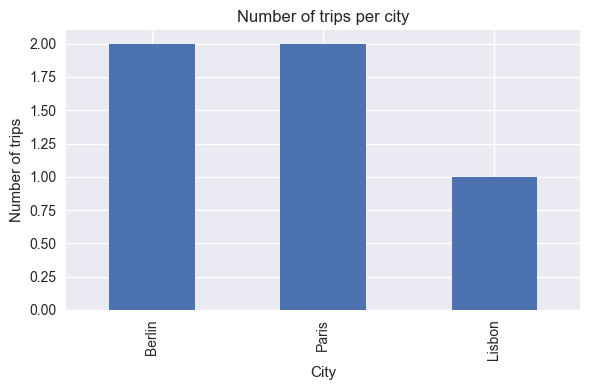

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

trips["city"].value_counts().plot(kind="bar", ax=ax)

ax.set_title("Number of trips per city")
ax.set_xlabel("City")
ax.set_ylabel("Number of trips")

fig.tight_layout()

- Paris and Berlin are the most visited cities
- the number of trips are a float

#### Scatterplot Budget vs Days

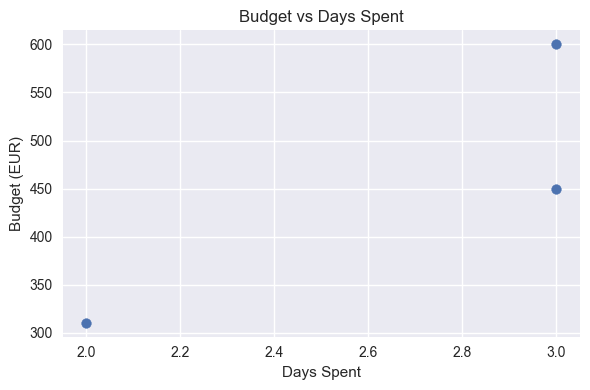

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(trips["days_spent"], trips["budget_eur"])

ax.set_title("Budget vs Days Spent")
ax.set_xlabel("Days Spent")
ax.set_ylabel("Budget (EUR)")

fig.tight_layout()

- Longer stays tend to cost more

#### Time Pattern

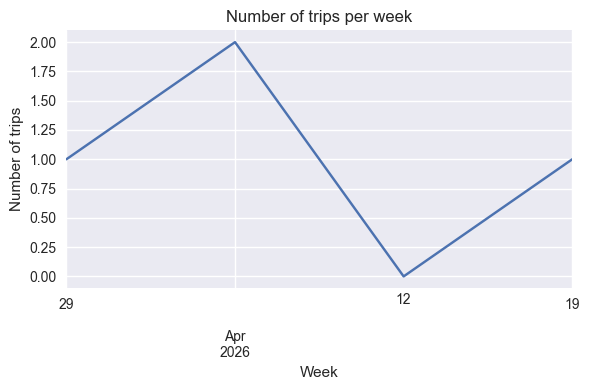

In [15]:
trips_by_date = trips.set_index("date").resample("W")["city"].count()

fig, ax = plt.subplots(figsize=(6, 4))
trips_by_date.plot(ax=ax)

ax.set_title("Number of trips per week")
ax.set_xlabel("Week")
ax.set_ylabel("Number of trips")

fig.tight_layout()

- The trips are concentrated in a short period of time.

In [17]:
figures_folder = Path("figures")
figures_folder.mkdir(exist_ok=True)
fig.savefig(figures_folder / "trips_budget_vs_days.pdf")

#### Findings

Considerados en conjunto, los tres gráficos cuentan una historia coherente sobre estos viajes. El gráfico de barras muestra que la actividad se concentra en unas pocas ciudades, con Paris y Berlin como destinos dominantes. El diagrama de dispersión sugiere una relación positiva entre la duración de la estancia y el presupuesto: las estancias más largas tienden a costar más. La serie temporal revela que casi todos los viajes ocurren en una ventana corta de pocas semanas, lo que indica un patrón estacional o un periodo de registro limitado más que un hábito de viaje continuo.

**Limitación:** el conjunto de datos es muy pequeño (5 filas) y contiene valores faltantes en `days_spent` y `budget_eur`, por lo que cualquier tendencia observada es solo indicativa y no estadísticamente robusta.

**Siguiente pregunta:** ¿se mantiene la relación entre duración y presupuesto al recopilar más viajes a lo largo de varios meses, o el coste por día varía sistemáticamente según la ciudad?